In [1]:
import os
import sys
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, '..')) # Adjust as needed
if project_root not in sys.path:
    sys.path.append(project_root) # add notebook to sys.path

In [2]:
import math

import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from matplotlib_inline import backend_inline

In [3]:
def use_svg_display():
    """Use the svg format to display a plot in Jupyter.

    Defined in :numref:`sec_calculus`"""
    backend_inline.set_matplotlib_formats('svg')

In [4]:
def show_heatmaps(matrices, xlabel, ylabel, titles=None, figsize=(2.5, 2.5),
                  cmap='Reds'):
    """Show heatmaps of matrices."""
    use_svg_display()
    num_rows, num_cols, _, _ = matrices.shape
    fig, axes = plt.subplots(num_rows, num_cols, figsize=figsize,
                                 sharex=True, sharey=True, squeeze=False)
    for i, (row_axes, row_matrices) in enumerate(zip(axes, matrices)):
        for j, (ax, matrix) in enumerate(zip(row_axes, row_matrices)):
            pcm = ax.imshow(matrix.detach().numpy(), cmap=cmap)
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            if j == 0:
                ax.set_ylabel(ylabel)
            if titles:
                ax.set_title(titles[j])
    fig.colorbar(pcm, ax=axes, shrink=0.6);

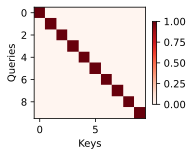

In [5]:
attention_weights = torch.eye(10).reshape((1, 1, 10, 10))
show_heatmaps(attention_weights, xlabel='Keys', ylabel='Queries')

In [6]:
def masked_softmax(X, valid_lens):
    """Perform softmax by masking elements on last axis.
    
    Args:
        X (torch.Tensor): (B, N, M) Input tensor to be masked, where
            B is the batch size, N is the number of queries, and M is 
            the number of keys
        valid_len (torch.Tensor): (B,) or (B, N) Tensor of type int
            describing how many elements in the sequence to keep

    Returns: 
        torch.Tensor: (B, N, M) Masked input array 
    """
    def _sequence_mask(X, valid_lens, value=0.0):
        """Expects X to be 2D Tensor (B, M), valid_lens 1D tensor (B)"""
        mask = torch.arange(X.shape[-1])[None, :] >= valid_lens[:, None]
        X[mask] = value
        return X

    B, N, M = X.shape
    if valid_lens is None:
        return F.softmax(X, dim=-1)
    else:
        if valid_lens.dim() == 1:
            valid_lens = torch.repeat_interleave(valid_lens, N)
        else:
            valid_lens = valid_lens.reshape(-1)
        X = _sequence_mask(X.reshape(-1, M), valid_lens, value=-1e6)
        return F.softmax(X.reshape((B, N, M)), dim=-1)

In [7]:
masked_softmax(torch.rand(3, 3, 4), torch.tensor([2, 3, 1]))

tensor([[[0.5888, 0.4112, 0.0000, 0.0000],
         [0.5495, 0.4505, 0.0000, 0.0000],
         [0.6558, 0.3442, 0.0000, 0.0000]],

        [[0.4525, 0.2958, 0.2516, 0.0000],
         [0.2901, 0.4752, 0.2347, 0.0000],
         [0.2581, 0.2702, 0.4716, 0.0000]],

        [[1.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000],
         [1.0000, 0.0000, 0.0000, 0.0000]]])

In [8]:
masked_softmax(torch.rand(2, 2, 4), torch.tensor([[1, 3], [2, 4]]))

tensor([[[1.0000, 0.0000, 0.0000, 0.0000],
         [0.3689, 0.3340, 0.2971, 0.0000]],

        [[0.5537, 0.4463, 0.0000, 0.0000],
         [0.1738, 0.2898, 0.2713, 0.2651]]])

In [9]:
class DotProductAttention(nn.Module):
    """Scaled dot product attention."""
    def __init__(self, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, queries, keys, values, valid_lens=None):
        """Computes masked dot product attention w/ Q, K, V
        
        Args:
            queries (Tensor): (B, N, D)
            keys (Tensor): (B, M, D)
            values (Tensor): (B, M, V)
            valid_lens (Tensor): (B) or (B, N)
            
        Returns:
            Tensor: (B, N, V)"""
        D = queries.shape[-1]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(D)
        self.attention_weights = masked_softmax(scores, valid_lens=valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [10]:
queries = torch.normal(0, 1, (2, 1, 2))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([3, 6])

attention = DotProductAttention(dropout=0.5)
attention.train()
print(attention(queries, keys, values, valid_lens).shape)
print(attention.attention_weights.shape)

torch.Size([2, 1, 4])
torch.Size([2, 1, 10])


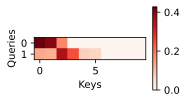

In [11]:
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

In [12]:
class AdditiveAttention(nn.Module):
    """Additive attention layer"""
    def __init__(self, num_hiddens, dropout):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=False)
        self.W_k = nn.LazyLinear(num_hiddens, bias=False)
        self.W_v = nn.LazyLinear(1, bias=False)

    def forward(self, queries, keys, values, valid_lens=None):
        """Computes additive attention w/ Q, K, V
        
        Args:
            queries (Tensor): (B, N, q)
            keys (Tensor): (B, M, k)
            values (Tensor): (B, M, v)
            valid_lens (Tensor): (B) or (B, N)
            
        Returns:
            Tensor: (B, N, v)"""
        features = self.W_q(queries).unsqueeze(2) + self.W_k(keys).unsqueeze(1)
        features = torch.tanh(features)
        scores = self.W_v(features).squeeze(-1) # (B, N, M)
        self.attention_weights = masked_softmax(scores, valid_lens=valid_lens)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [13]:
queries = torch.normal(0, 1, (2, 1, 20))
keys = torch.normal(0, 1, (2, 10, 2))
values = torch.normal(0, 1, (2, 10, 4))
valid_lens = torch.tensor([3, 6])

attention = AdditiveAttention(num_hiddens=8, dropout=0.1)
attention.eval()
print(attention(queries, keys, values, valid_lens).shape)
print(attention.attention_weights.shape)


torch.Size([2, 1, 4])
torch.Size([2, 1, 10])


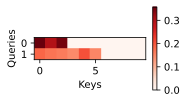

In [14]:
show_heatmaps(attention.attention_weights.reshape((1, 1, 2, 10)),
                  xlabel='Keys', ylabel='Queries')

### Bahdanau attention: Sequence-to-sequence translation

Define model

In [15]:
from utils.data import get_data_mt, build_mt
from utils.models import Seq2SeqEncoder, Seq2Seq, Decoder, init_seq2seq, Seq2SeqDecoder
from utils.train import fit_mt, loss_fn_mt

In [16]:
class AttentionDecoder(Decoder):
    def __init__(self):
        super().__init__()
    
    @property
    def attention_weights(self):
        raise NotImplementedError

In [17]:
class Seq2SeqAttentionDecoder(AttentionDecoder):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0):
        super().__init__()
        self.attention = AdditiveAttention(num_hiddens, dropout)
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size + num_hiddens, 
                          num_hiddens, num_layers, batch_first=True)
        self.dense = nn.Linear(num_hiddens, vocab_size)
        self.apply(init_seq2seq)

    def init_state(self, enc_outputs, enc_valid_lens):
        """Returns context vector, which is final hidden state
        
        Inputs:
        (outputs, hidden_state) (tuple[Tensor]): ((B, N, H), (L, B, H)) 
            hidden states at last layer, final hidden state
        enc_valid_lens (Tensor): (B) number of non-padded tokens

        Outputs:
        context (torch.Tensor): (batch_size, hidden_dim) final hidden state
        """
        outputs, hidden = enc_outputs
        return outputs, hidden, enc_valid_lens

    def forward(self, X, init_state):
        enc_outputs, hidden_state, enc_valid_lens = init_state
        X = self.embedding(X).permute(1, 0, 2)
        outputs, self._attention_weights = [], []
        for x in X:
            # use last layer, shape=(B, 1, H)
            query = hidden_state[-1].unsqueeze(dim=1)
            context = self.attention(
                query, enc_outputs, enc_outputs, valid_lens=enc_valid_lens)
            x = torch.cat((context, x.unsqueeze(dim=1)), dim=-1)
             # this only works if num_layers in encoder is same as decoder
            out, hidden_state = self.rnn(x, hidden_state)
            outputs.append(out)
            self._attention_weights.append(self.attention.attention_weights)
        outputs = torch.cat(outputs, dim=1)
        outputs = self.dense(outputs)
        return outputs, hidden_state

    @property
    def attention_weights(self):
        return self._attention_weights

Test model on inputs

In [18]:
src_vocab_size, tgt_vocab_size, embed_size, num_hiddens, num_layers = 10, 11, 8, 16, 2
batch_size, num_steps = 4, 7
encoder = Seq2SeqEncoder(src_vocab_size, embed_size, num_hiddens, num_layers)
decoder = Seq2SeqAttentionDecoder(tgt_vocab_size, embed_size, num_hiddens,
                                  num_layers)
X = torch.zeros((batch_size, num_steps), dtype=torch.long)
enc_all_outputs = encoder(X)
init_state = decoder.init_state(enc_all_outputs, None)
print(f"init state is {list(state.shape for state in init_state if state is not None)}")
output, state = decoder(X, init_state)
print(f"output.shape = {output.shape}, expected = ({batch_size, num_steps, tgt_vocab_size})")
print(f"state is {state.shape}")

init state is [torch.Size([4, 7, 16]), torch.Size([2, 4, 16])]
output.shape = torch.Size([4, 7, 11]), expected = ((4, 7, 11))
state is torch.Size([2, 4, 16])


Train model

In [19]:
batch_size = 128
num_steps = 10
num_train = 1024
num_val = 512
embed_size = 256
hidden_size = 256
num_layers = 2
dropout = 0.2
num_epochs = 30
lr = 0.005

In [20]:
train_dl, val_dl, src_vocab, tgt_vocab = get_data_mt(batch_size, num_steps, num_train, num_val)
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, hidden_size, num_layers, dropout=dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, hidden_size, num_layers, dropout=dropout)
model = Seq2Seq(encoder, decoder, tgt_vocab['<pad>'])
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
loss_fn = lambda Y_hat, Y: loss_fn_mt(model, Y_hat, Y)

In [21]:
for batch in train_dl:
    enc_X, dec_X, src_valid_len, _ = batch
    enc_outputs, hidden_state = encoder(enc_X, src_valid_len)
    X = decoder.embedding(enc_X).permute(1, 0, 2)
    print(X.shape)
    outputs = []
    for x in X:
        query = hidden_state[-1].unsqueeze(dim=1)
        context = decoder.attention(query, enc_outputs, enc_outputs, valid_lens=src_valid_len)
        x = torch.cat((context, x.unsqueeze(dim=1)), dim=-1)
        out, hidden_state = decoder.rnn(x, hidden_state)
        print(out.shape)
        outputs.append(out)
    outputs = torch.cat(outputs, dim=1)
    print(outputs.shape)
    outputs = decoder.dense(outputs)
    print(outputs.shape)
    break

torch.Size([10, 128, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 1, 256])
torch.Size([128, 10, 256])
torch.Size([128, 10, 466])


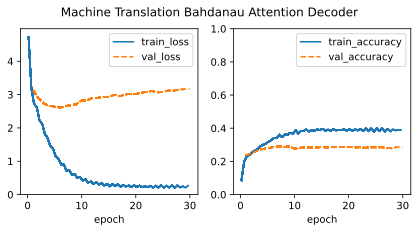

In [22]:
model = fit_mt(train_dl, val_dl, model, optimizer, loss_fn, num_epochs, 
       id="Machine Translation Bahdanau Attention Decoder")

#### Unroll model predictions

In [24]:
for batch in val_dl:
    outputs, _ = model.predict_step(batch, num_steps)
    print(outputs.shape)
    break

torch.Size([128, 10])


#### Make BLEU Predictions

In [25]:
from utils.metrics import bleu

In [26]:
engs = ['go .', 'i lost .', 'he\'s calm .', 'i\'m home .']
fras = ['va !', 'j\'ai perdu .', 'il est calme .', 'je suis chez moi .']
arrays = build_mt(engs, fras, src_vocab, tgt_vocab)
preds, _ = model.predict_step(arrays, num_steps)
for en, fr, p in zip(engs, fras, preds):
    translation = []
    for token in tgt_vocab.to_tokens(p):
        if token == '<eos>':
            break
        translation.append(token)
    print(f'{en} => {translation}, bleu: '
        f'{bleu(" ".join(translation), fr, k=2):.3f} '
        f'Target: {fr}')

go . => ['va', 'va', 'va', 'va', 'va', 'va', 'va', 'va', 'va', 'va'], bleu: 0.000 Target: va !
i lost . => ["j'ai", 'perdu', "j'ai", 'perdu', "j'ai", 'perdu', "j'ai", 'perdu', "j'ai", 'perdu'], bleu: 0.258 Target: j'ai perdu .
he's calm . => ['il', 'est', '<unk>', '.', 'calme', '.', 'calme', '.', 'calme', '.'], bleu: 0.434 Target: il est calme .
i'm home . => ['je', 'suis', 'je', 'suis', 'je', 'suis', 'je', 'suis', 'je', 'suis'], bleu: 0.258 Target: je suis chez moi .


# Multi-Head Attention

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, num_hiddens, num_heads, dropout=0, bias=False):
        super().__init__()
        self.num_heads = num_heads
        self.attention = DotProductAttention(dropout)
        self.W_q = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_k = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_v = nn.LazyLinear(num_hiddens, bias=bias)
        self.W_o = nn.LazyLinear(num_hiddens, bias=bias)
    
    def forward(self, queries, keys, values, valid_lens):
        queries = self.W_q(queries)
        keys = self.W_k(keys)
        values = self.W_k(values)

        # (B, N or M, H) -> (B * h, N or M, H/h)
        queries = self.transpose_qkv(queries)
        keys = self.transpose_qkv(keys)
        values = self.transpose_qkv(values)

        if valid_lens is not None:
            valid_lens = torch.repeat_interleave(
                valid_lens, repeats=self.num_heads, dim=0
            )

        # (B * h, M, H/h)
        output = self.attention(queries, keys, values, valid_lens)
        # (B * h, M, H/h) -> (B, M, H)
        output_concat = self.transpose_out(output)
        return self.W_o(output_concat)

    def transpose_qkv(self, X):
        X = X.reshape(X.shape[0], X.shape[1], self.num_heads, -1)
        X = X.permute(0, 2, 1, 3)
        return X.reshape(-1, X.shape[2], X.shape[3])

    def transpose_out(self, X):
        X = X.reshape(-1, self.num_heads, X.shape[1], X.shape[2])
        X = X.permute(0, 2, 1, 3)
        return X.reshape(X.shape[0], X.shape[1], -1)


In [28]:
num_hiddens, num_heads = 100, 5
attention = MultiHeadAttention(num_hiddens, num_heads, 0.2)
batch_size, num_queries, num_kvpairs = 2, 4, 6
valid_lens = torch.tensor([3, 2])
X = torch.ones((batch_size, num_queries, num_hiddens))
Y = torch.ones((batch_size, num_kvpairs, num_hiddens))
print(attention(X, Y, Y, valid_lens).shape)


torch.Size([2, 4, 100])


# Self-Attention

In [30]:
num_hiddens, num_heads = 100, 5
batch_size, num_queries, valid_lens = 2, 4, torch.tensor([3, 2])
attention = MultiHeadAttention(num_hiddens, num_heads, 0.2)
X = torch.ones((batch_size, num_queries, num_hiddens))
print(attention(X, X, X, valid_lens).shape)

torch.Size([2, 4, 100])


# Positional Encoding